In [21]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

In [22]:
# Publication-quality plot settings
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 24,
    'axes.labelsize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'lines.linewidth': 2.5,
    'axes.linewidth': 1.5,
    'grid.linewidth': 0.8,
    'grid.alpha': 0.3,
})

# Kelly's colors of maximum contrast — maximally distinct 6 colors
COLORS = [
    '#4363D8',  # Blue
    '#3CB44B',  # Green
    '#E6194B',  # Red
    '#42D4F4',  # Cyan
    '#F58231',  # Orange
    '#911EB4',  # Purple
    '#FFD700',  # Gold
]

In [23]:
def exponential_moving_average(data, smoothing):
    """Apply exponential moving average smoothing (TensorBoard-style)
    
    TensorBoard uses a debiased exponential moving average to ensure
    smooth curves even at the beginning of the sequence.
    """
    if smoothing == 0:
        return data
    
    smoothed = np.zeros_like(data)
    last = 0  # Start with 0, not data[0]
    debias_weight = 0
    
    for i, point in enumerate(data):
        last = last * smoothing + (1 - smoothing) * point
        debias_weight = debias_weight * smoothing + (1 - smoothing)
        smoothed[i] = last / debias_weight  # Debiasing step
    
    return smoothed


def rolling_std(data, window=200):
    """Compute rolling standard deviation over a sliding window."""
    result = np.zeros_like(data, dtype=float)
    half = window // 2
    for i in range(len(data)):
        start = max(0, i - half)
        end = min(len(data), i + half)
        result[i] = np.std(data[start:end])
    return result


In [24]:
drill_title = "Drill P&P - Training Reward Curves"
drill_checkpoints = [
    "runs/DrillDiabloGraspCustom3/DiabloGraspCustom3_14-08-42-05-drill/summaries/events.out.tfevents.*",
    "runs/drill_grasp_moe_num_actor_2_seed_1234_15-19-45-45/summaries/events.out.tfevents.*",
]

mug_title = "Mug P&P - Training Reward Curves"
mug_checkpoints = [
    "runs/MugDiabloGraspCustom3/DiabloGraspCustom3_13-23-11-24/summaries/events.out.tfevents.*",
    "runs/mug_grasp_moe_num_actor_2_seed_42_14-13-24-55/summaries/events.out.tfevents.*",
]

dumbbell_title = "Dumbbell P&P - Training Reward Curves"
dumbbell_checkpoints = [
    "runs/dumbbell_grasp_moe_num_actor_1_seed_27404_17-10-37-27/summaries/events.out.tfevents.*",
    "runs/dumbbell_grasp_moe_num_actor_2_seed_2027_17-09-02-30/summaries/events.out.tfevents.*",
]

labels = [
    "PPO",
    "MoE",
]

In [25]:
def load_tensorboard_data(checkpoints, labels, tag="rewards/iter", max_iters=None):
    """
    Load TensorBoard event files and group rewards by label.
    
    Parameters:
    -----------
    checkpoints : list of str
        List of file patterns for TensorBoard event files (supports wildcards)
    labels : list of str
        List of labels corresponding to each checkpoint
    tag : str, optional
        TensorBoard scalar tag to extract (default: "rewards/iter")
    max_iters : int or None, optional
        Maximum number of iterations to include. If None, use all available data.
        If specified, data will be trimmed to min(min_length, max_iters)
    
    Returns:
    --------
    grouped_rewards : dict
        Dictionary mapping labels to lists of reward arrays
    common_timesteps : np.ndarray
        Common timestep array aligned to minimum length across all runs (1-indexed)
    """
    # Dictionary to group rewards by label
    grouped_rewards = {}
    
    for checkpoint, label in zip(checkpoints, labels):
        # Find all matching event files
        event_files = glob(checkpoint)
        
        if not event_files:
            print(f"Warning: No files found for pattern: {checkpoint}")
            continue
        
        # Initialize list for this label if not exists
        if label not in grouped_rewards:
            grouped_rewards[label] = []
        
        for event_file in event_files:
            print(f"Loading: {event_file}")
            
            # Load TensorBoard event file
            ea = EventAccumulator(event_file)
            ea.Reload()
            
            # Get the specified tag
            if tag in ea.Tags()['scalars']:
                scalar_events = ea.Scalars(tag)
                
                # Extract values (step, value, wall_time)
                reward_data = np.array([event.value for event in scalar_events])
                grouped_rewards[label].append(reward_data)
                
                print(f"  Loaded {len(reward_data)} data points from {label}")
            else:
                print(f"  Warning: '{tag}' tag not found in {event_file}")
                print(f"  Available tags: {ea.Tags()['scalars']}")
    
    # Find the minimum length across all runs for alignment
    min_length = min(len(data) for group in grouped_rewards.values() for data in group)
    print(f"\nMinimum timesteps across all runs: {min_length}")
    
    # Apply max_iters limit if specified
    if max_iters is not None:
        final_length = min(min_length, max_iters)
        print(f"Maximum iterations limit: {max_iters}")
        print(f"Final trimmed length: {final_length}")
    else:
        final_length = min_length
    
    # Trim all arrays to the same length and create common timesteps
    for label in grouped_rewards:
        grouped_rewards[label] = [data[:final_length] for data in grouped_rewards[label]]
    
    # Create 1-indexed timesteps (1 to final_length)
    common_timesteps = np.arange(1, final_length + 1)
    
    print(f"\nGrouped rewards summary:")
    for label, group in grouped_rewards.items():
        print(f"  {label}: {len(group)} run(s), {len(group[0])} timesteps each")
    
    return grouped_rewards, common_timesteps

In [26]:
# Example: Load data for a single task
# Option 1: Load all available data
# grouped_rewards, common_timesteps = load_tensorboard_data(drill_checkpoints, labels)

# Option 2: Limit to maximum 1500 iterations
# grouped_rewards, common_timesteps = load_tensorboard_data(drill_checkpoints, labels, max_iters=1500)

In [27]:
from matplotlib.ticker import FuncFormatter

def thousands_formatter(x, pos):
    """Format y-axis values in thousands"""
    return f'{int(x/1000)}'

def plot_training_curves(grouped_rewards, common_timesteps, title, 
                         smoothing=0.9, figsize=(12, 6), 
                         output_filename="total_rewards.png"):
    """
    Plot training reward curves with mean and standard deviation.
    
    Parameters:
    -----------
    grouped_rewards : dict
        Dictionary mapping labels to lists of reward arrays
    common_timesteps : np.ndarray
        Common timestep array for x-axis
    title : str
        Plot title
    smoothing : float, optional
        Smoothing factor for exponential moving average (default: 0.9)
    figsize : tuple, optional
        Figure size (width, height) in inches (default: (12, 6))
    output_filename : str, optional
        Filename to save the plot (default: "total_rewards.png")
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    for i, (label, group) in enumerate(grouped_rewards.items()):
        color = COLORS[i % len(COLORS)]
        raw_group = np.array(group)  # shape: (n_runs, n_timesteps)
        
        if len(group) > 1:
            # Multiple runs: inter-run mean/std, then smooth the mean
            raw_mean = np.mean(raw_group, axis=0)
            raw_std  = np.std(raw_group, axis=0)
            mean = exponential_moving_average(raw_mean, smoothing)
            std  = exponential_moving_average(raw_std, smoothing)
        else:
            # Single run: smooth mean, rolling std on raw data before smoothing
            raw = raw_group[0]
            mean = exponential_moving_average(raw, smoothing)
            std  = exponential_moving_average(rolling_std(raw, window=200), smoothing)
        
        print(f"Plotting '{label}': mean final = {mean[-1]:.2f}, std final = {std[-1]:.2f}")
        
        display_label = r"$\mathbf{" + label + "}$" if label == "EPPO" else label
        
        ax.plot(common_timesteps, mean, label=display_label, alpha=0.9,
                color=color, linestyle="-", linewidth=2.5)
        ax.fill_between(common_timesteps, mean - std, mean + std,
                        alpha=0.2, color=color)
    
    # Format axes
    ax.set_ylim(bottom=0)  # Start y-axis at 0
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    
    # Set x-axis limits and ticks to show max value
    min_x = common_timesteps[0]
    max_x = common_timesteps[-1]
    ax.set_xlim(min_x, max_x)
    # Create evenly spaced ticks that include min and max value
    num_ticks = 6
    x_ticks = np.linspace(min_x, max_x, num_ticks, dtype=int)
    ax.set_xticks(x_ticks)
    
    ax.set_xlabel("Iterations")
    ax.set_ylabel(r"Reward (×10$^3$)")
    ax.set_title(title)
    ax.grid(True, alpha=0.5, linestyle='--')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.legend()
    
    plt.tight_layout()
    
    # Save figure
    fig.savefig(output_filename, dpi=300, bbox_inches='tight', pad_inches=0.1)
    print(f"Saved: {output_filename}")
    
    return fig, ax

DRILL P&P
Loading: runs/DrillDiabloGraspCustom3/DiabloGraspCustom3_14-08-42-05-drill/summaries/events.out.tfevents.1776127330.erc-rtx3050
  Loaded 2000 data points from PPO
Loading: runs/drill_grasp_moe_num_actor_2_seed_1234_15-19-45-45/summaries/events.out.tfevents.1776253547.erc-rtx5070ti
  Loaded 2000 data points from MoE

Minimum timesteps across all runs: 2000
Maximum iterations limit: 1500
Final trimmed length: 1500

Grouped rewards summary:
  PPO: 1 run(s), 1500 timesteps each
  MoE: 1 run(s), 1500 timesteps each
Plotting 'PPO': mean final = 43080.16, std final = 1575.46
Plotting 'MoE': mean final = 47708.89, std final = 1419.19
Saved: drill_total_rewards.png


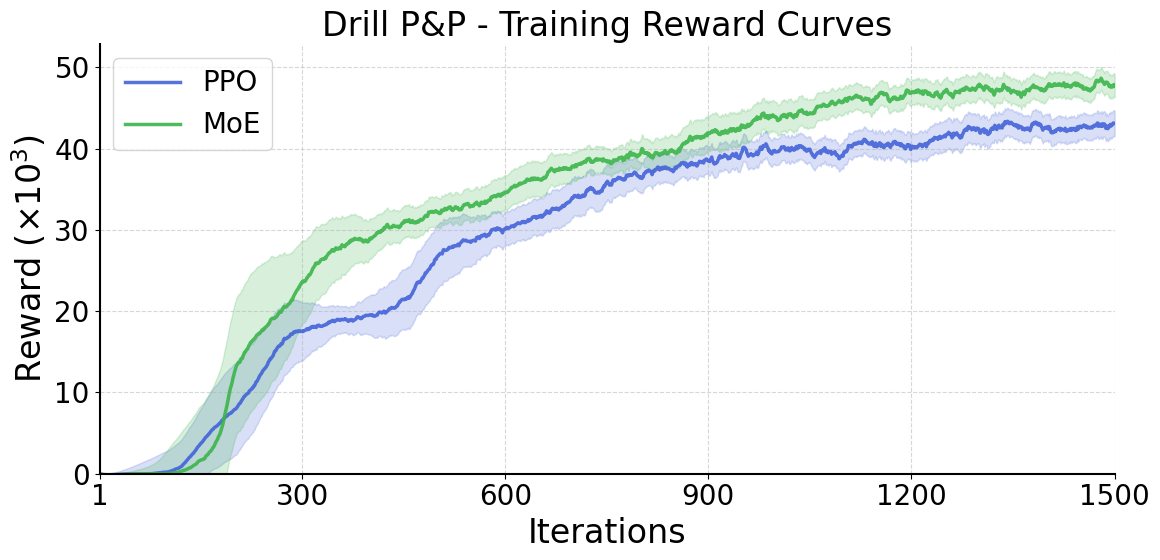

In [ ]:
# Load and plot Drill data
print("=" * 80)
print("DRILL P&P")
print("=" * 80)
drill_rewards, drill_timesteps = load_tensorboard_data(drill_checkpoints, labels, max_iters=1500)

fig_drill, ax_drill = plot_training_curves(
    drill_rewards, 
    drill_timesteps, 
    drill_title, 
    smoothing=0.9,
    output_filename="figures/drill_total_rewards.png"
)
plt.show()

MUG P&P
Loading: runs/MugDiabloGraspCustom3/DiabloGraspCustom3_13-23-11-24/summaries/events.out.tfevents.1776093090.erc-rtx3050
  Loaded 2000 data points from PPO
Loading: runs/mug_grasp_moe_num_actor_2_seed_42_14-13-24-55/summaries/events.out.tfevents.1776144297.erc-rtx5070ti
  Loaded 2000 data points from MoE

Minimum timesteps across all runs: 2000
Maximum iterations limit: 1500
Final trimmed length: 1500

Grouped rewards summary:
  PPO: 1 run(s), 1500 timesteps each
  MoE: 1 run(s), 1500 timesteps each
Plotting 'PPO': mean final = 42997.90, std final = 1392.27
Plotting 'MoE': mean final = 47656.57, std final = 1398.47
Saved: mug_total_rewards.png


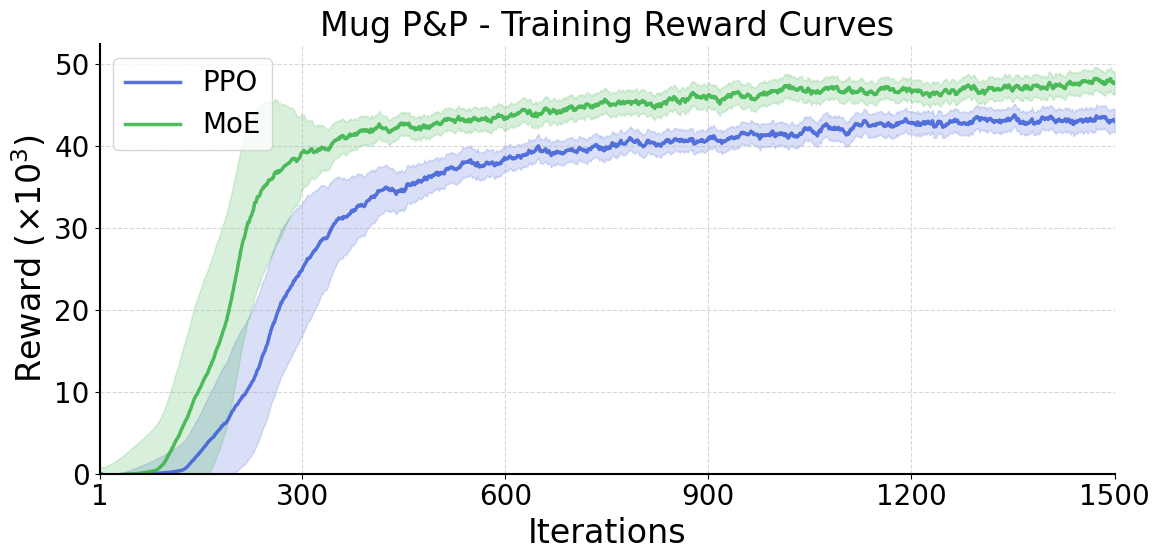

In [ ]:
# Load and plot Mug data
print("=" * 80)
print("MUG P&P")
print("=" * 80)
mug_rewards, mug_timesteps = load_tensorboard_data(mug_checkpoints, labels, max_iters=1500)

fig_mug, ax_mug = plot_training_curves(
    mug_rewards, 
    mug_timesteps, 
    mug_title, 
    smoothing=0.9,
    output_filename="figures/mug_total_rewards.png"
)
plt.show()

DUMBBELL P&P
Loading: runs/dumbbell_grasp_moe_num_actor_1_seed_27404_17-10-37-27/summaries/events.out.tfevents.1776393449.ROG-Strix-SCAR-16-G634JZR-24
  Loaded 1664 data points from PPO
Loading: runs/dumbbell_grasp_moe_num_actor_2_seed_2027_17-09-02-30/summaries/events.out.tfevents.1776387752.erc-rtx5070ti
  Loaded 2000 data points from MoE

Minimum timesteps across all runs: 1664
Maximum iterations limit: 1500
Final trimmed length: 1500

Grouped rewards summary:
  PPO: 1 run(s), 1500 timesteps each
  MoE: 1 run(s), 1500 timesteps each
Plotting 'PPO': mean final = 38267.34, std final = 1413.94
Plotting 'MoE': mean final = 48414.05, std final = 1262.62
Saved: dumbbell_total_rewards.png


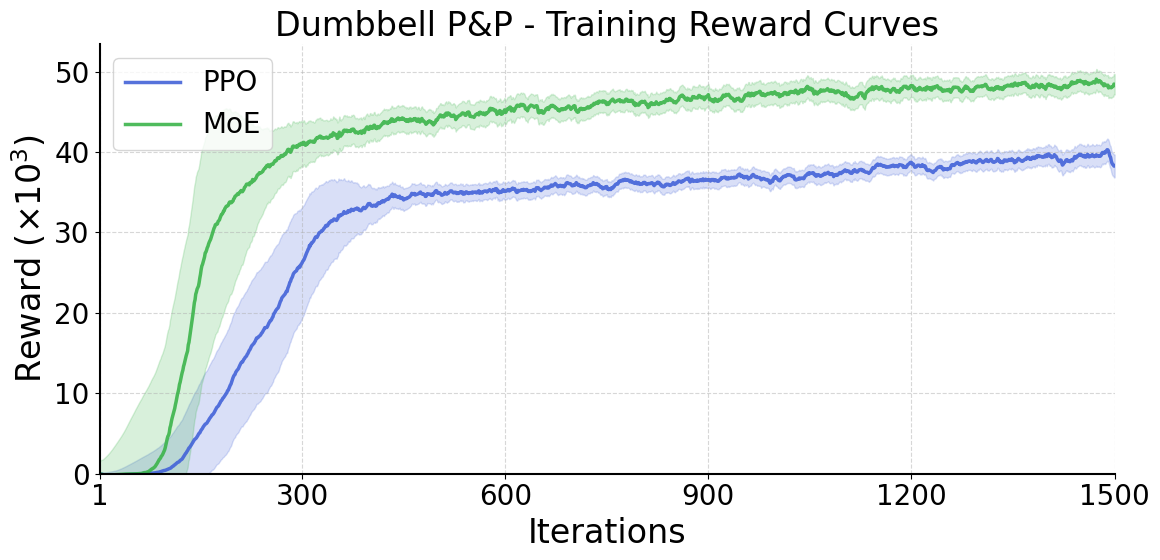

In [ ]:
# Load and plot Dumbbell data
print("=" * 80)
print("DUMBBELL P&P")
print("=" * 80)
dumbbell_rewards, dumbbell_timesteps = load_tensorboard_data(dumbbell_checkpoints, labels, max_iters=1500)

fig_dumbbell, ax_dumbbell = plot_training_curves(
    dumbbell_rewards, 
    dumbbell_timesteps, 
    dumbbell_title, 
    smoothing=0.9,
    output_filename="figures/dumbbell_total_rewards.png"
)
plt.show()